# Contrastive Born Machine

**Motivation:** Both TEBD and the QAOA-inspired mixers fail to improve on DMRG after warm-up
because they either stall (block fixed-point) or add noise (random mixer).

**This notebook** implements the *contrastive phase* idea:
add explicit model samples to the pseudo-Hamiltonian so that the update simultaneously
- **pushes up** probability on training data (positive/data phase), and  
- **pushes down** probability on regions currently over-represented by the model (negative/model phase).

The resulting contrastive objective is:
$$\mathcal{L}_{\rm CD} = -\frac{1}{N}\sum_n \log p_\psi(x^{(n)}) + \frac{\alpha}{M_{\rm neg}}\sum_m \log p_\psi(\hat{x}^{(m)})$$
where $\hat{x}^{(m)} \sim p_\psi$ are drawn at the start of each epoch.

The gradient Riemannian step becomes:
$$\Theta_{\rm new} = \bigl(1 - 2\eta(1-\alpha)\bigr)\,\Theta
  + \eta\, d_{\rm data} - \eta\alpha\, d_{\rm model}$$

For MPS the negative phase is cheap: sampling costs $\mathcal{O}(M_{\rm neg}\cdot M\cdot d\cdot D^2)$
and the extra environment computation is $\mathcal{O}(M_{\rm neg}\cdot M\cdot D^2)$.

In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, "../.."))
Pkg.resolve()
Pkg.instantiate()

using MPSFast
using MPSFast.Encoders
using Random, LinearAlgebra, Statistics, Printf
using Plots; default(size=(900,500), lw=2, legend=:topright)

  Activating project at `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl`
     Project No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Project.toml`
    Manifest No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Manifest.toml`


---
## 1. Dataset (same drifted random-walk as previous notebooks)

In [2]:
function synthetic_paths_labels(N, M; drift=0.15, σ=1.0, rng=Random.default_rng())
    paths  = Matrix{Float64}(undef, N, M)
    for i in 1:N
        dr = (rand(rng, 1:2) == 1) ? drift : -drift
        paths[i, :] = cumsum(dr .+ σ .* randn(rng, M))
    end
    return paths
end

rng      = MersenneTwister(42)
N_train  = 2_000
M_path   = 15
m_bits   = 3          # d = 2^m = 8 bins
Ml       = M_path

train_paths = synthetic_paths_labels(N_train, M_path; rng=rng)
enc         = BasisEncoder(m_bits)
fit_grid!(enc, train_paths)
d        = site_dim(enc)   # = 8
xi_train = encode_paths(enc, train_paths)

@printf "Training set: %d sequences, M=%d sites, d=%d bins\n" N_train M_path d

Training set: 2000 sequences, M=15 sites, d=8 bins


---
## 2. Shared helper functions (from tebd_born_machine)

In [3]:
# ── Environment contractions ──────────────────────────────────────────────────
# (copied verbatim from tebd_born_machine.ipynb)

function build_left_envs(mps::Vector{Array{T,3}}, xi::AbstractMatrix{<:Integer}) where T
    M_sites = length(mps); N = size(xi, 1)
    L = Vector{Matrix{T}}(undef, M_sites + 1)
    L[1] = ones(T, 1, N)
    for j in 1:M_sites
        Dl, d_loc, Dr = size(mps[j])
        Lnew = zeros(T, Dr, N)
        for n in 1:N
            Lnew[:, n] = mps[j][:, xi[n, j], :]' * L[j][:, n]
        end
        L[j+1] = Lnew
    end
    return L
end

function build_right_envs(mps::Vector{Array{T,3}}, xi::AbstractMatrix{<:Integer}) where T
    M_sites = length(mps); N = size(xi, 1)
    R = Vector{Matrix{T}}(undef, M_sites + 1)
    R[M_sites + 1] = ones(T, 1, N)
    for j in M_sites:-1:1
        Dl, d_loc, Dr = size(mps[j])
        Rnew = zeros(T, Dl, N)
        for n in 1:N
            Rnew[:, n] = mps[j][:, xi[n, j], :] * R[j+1][:, n]
        end
        R[j] = Rnew
    end
    return R
end

function update_left_env!(L, mps, xi, k)
    N = size(xi, 1)
    Dl, d_loc, Dr = size(mps[k])
    Lnew = zeros(eltype(L[1]), Dr, N)
    for n in 1:N
        Lnew[:, n] = mps[k][:, xi[n, k], :]' * L[k][:, n]
    end
    L[k+1] = Lnew
end

function update_right_env!(R, mps, xi, k)
    N = size(xi, 1)
    Dl, d_loc, Dr = size(mps[k])
    Rnew = zeros(eltype(R[1]), Dl, N)
    for n in 1:N
        Rnew[:, n] = mps[k][:, xi[n, k], :] * R[k+1][:, n]
    end
    R[k] = Rnew
end

function all_amplitudes(L, M_sites)
    return vec(L[M_sites + 1])
end

function nll_mps(mps, xi; n_samples=400)
    N = size(xi, 1)
    idx = randperm(N)[1:min(n_samples, N)]
    L   = build_left_envs(mps, xi[idx, :])
    amp = all_amplitudes(L, length(mps))
    return -mean(2 .* log.(abs.(amp) .+ 1e-40))
end

println("✓  environment functions defined")

✓  environment functions defined


In [4]:
# ── TEBD gate primitives (not exported by MPSFast — defined here) ─────────────

function local_heff_blocks(
    xi::AbstractMatrix{<:Integer},
    j::Int,
    d_loc::Int,
    Dl::Int,
    Dr::Int,
    L::Vector{Matrix{T}},
    R::Vector{Matrix{T}},
    amplitudes::Vector{T};
    clip_factor::Real = 0.1,
) where T
    N_data = size(xi, 1)
    Dbd    = Dl * Dr
    pmin   = T(clip_factor) / N_data
    blocks = [zeros(T, Dbd, Dbd) for _ in 1:d_loc, _ in 1:d_loc]
    for n in 1:N_data
        pn  = max(amplitudes[n]^2, pmin)
        sj  = xi[n, j];  sj1 = xi[n, j+1]
        k   = vec(L[j][:, n] * R[j+2][:, n]')
        blocks[sj, sj1] .+= (k * k') ./ pn
    end
    for s in 1:d_loc, s1 in 1:d_loc
        blocks[s, s1] ./= N_data
    end
    return blocks
end

function apply_imaginary_gate!(
    mps::Vector{Array{T,3}},
    j::Int,
    blocks::Matrix{Matrix{T}},
    Δτ::Real,
    D_max::Int,
    ε::Real = 1e-10,
) where T
    Dl    = size(mps[j], 1)
    d_loc = size(mps[j], 2)
    Dr    = size(mps[j+1], 3)
    Theta = reshape(
        reshape(mps[j], Dl * d_loc, size(mps[j], 3)) *
        reshape(mps[j+1], size(mps[j+1], 1), d_loc * Dr),
        Dl, d_loc, d_loc, Dr,
    )
    Theta_new = similar(Theta)
    for s in 1:d_loc, s1 in 1:d_loc
        M     = blocks[s, s1]
        v     = vec(Theta[:, s, s1, :])
        F     = eigen(Symmetric(M))
        λ_max = F.values[end]
        w     = exp.(T(Δτ) .* (F.values .- λ_max))
        Theta_new[:, s, s1, :] = reshape(F.vectors * (w .* (F.vectors' * v)), Dl, Dr)
    end
    nrm = norm(Theta_new)
    nrm < 1e-30 && return 1
    Theta_new ./= nrm
    F_svd = svd(reshape(Theta_new, Dl * d_loc, d_loc * Dr))
    χ     = max(1, min(D_max, count(>(T(ε)), F_svd.S)))
    mps[j]   = reshape(F_svd.U[:, 1:χ],                              Dl, d_loc, χ)
    mps[j+1] = reshape(Diagonal(F_svd.S[1:χ]) * F_svd.Vt[1:χ, :],   χ, d_loc, Dr)
    return χ
end

# ── local_data_term ────────────────────────────────────────────────────────────
# ddata[α,s,s₁,β] = (2/N) Σ_{n: xⱼ=s, xⱼ₊₁=s₁} Lₙ[α] Rₙ[β] / ψ(xⁿ)

function local_data_term(
    xi         :: AbstractMatrix{<:Integer},
    j          :: Int,
    d_loc      :: Int,
    Dl         :: Int,
    Dr         :: Int,
    L          :: Vector{Matrix{T}},
    R          :: Vector{Matrix{T}},
    amplitudes :: Vector{T};
    clip_factor :: Real = 0.1,
) where T
    N_data = size(xi, 1)
    pmin   = T(clip_factor) / N_data
    ddata  = zeros(T, Dl, d_loc, d_loc, Dr)
    for n in 1:N_data
        pn     = max(amplitudes[n]^2, pmin)
        weight = amplitudes[n] / pn
        sj     = xi[n, j];  sj1 = xi[n, j + 1]
        lvec   = L[j][:, n];  rvec = R[j + 2][:, n]
        @inbounds for β in 1:Dr, α in 1:Dl
            ddata[α, sj, sj1, β] += weight * lvec[α] * rvec[β]
        end
    end
    ddata .*= T(2) / N_data
    return ddata
end

println("✓  local_heff_blocks, apply_imaginary_gate!, local_data_term defined")

✓  local_heff_blocks, apply_imaginary_gate!, local_data_term defined


In [5]:
# ── Import TEBD and Riemannian trainers from tebd_born_machine ────────────────

function train_mps_tebd!(
    mps::Vector{Array{T,3}},
    xi::AbstractMatrix{<:Integer},
    n_epochs::Int,
    Δτ::Real,
    D_max::Int;
    ε::Real          = 1e-10,
    clip_factor::Real = 0.1,
    verbose::Bool    = true,
    nll_samples::Int = 400,
) where T
    M_sites = length(mps)
    nll_hist = Float64[]

    for ep in 1:n_epochs
        # ── Build full environments at start of epoch ─────────────────────
        L    = build_left_envs(mps, xi)
        R    = build_right_envs(mps, xi)
        amps = all_amplitudes(L, M_sites)

        # ── Forward sweep: odd bonds (j=1,3,5,...) ────────────────────────
        # After each gate, the left envs L[j+1..M+1] become stale.
        # Fix: propagate L from j onwards — R[j+2] is still correct since
        # sites j+2..M have not yet been touched in this sweep.
        for j in 1:2:M_sites-1
            Dl    = size(mps[j], 1)
            d_loc = size(mps[j], 2)
            Dr    = size(mps[j+1], 3)
            blks  = local_heff_blocks(xi, j, d_loc, Dl, Dr, L, R, amps;
                                      clip_factor=clip_factor)
            apply_imaginary_gate!(mps, j, blks, Δτ, D_max, ε)
            # Incrementally refresh L[j+1..M+1] so next gate has fresh amplitudes
            for k in j:M_sites
                update_left_env!(L, mps, xi, k)
            end
            amps = all_amplitudes(L, M_sites)
        end

        # Rebuild R from the updated forward-sweep MPS; L is already fresh
        R    = build_right_envs(mps, xi)

        # ── Backward sweep: even bonds (j=M-1,M-3,...) ───────────────────
        # After each backward gate, R[j..1] become stale.
        # Fix: update R[j+1] and R[j] (the two modified sites), then propagate
        # R leftward.  L[j-1] is still correct (sites 1..j-1 untouched in
        # the backward sweep so far).
        for j in (M_sites-1):-2:2
            Dl    = size(mps[j], 1)
            d_loc = size(mps[j], 2)
            Dr    = size(mps[j+1], 3)
            blks  = local_heff_blocks(xi, j, d_loc, Dl, Dr, L, R, amps;
                                      clip_factor=clip_factor)
            apply_imaginary_gate!(mps, j, blks, Δτ, D_max, ε)
            # Refresh R from j+1 down to 1, and L for fresh amplitudes
            for k in j+1:-1:1
                update_right_env!(R, mps, xi, k)
            end
            for k in j:M_sites
                update_left_env!(L, mps, xi, k)
            end
            amps = all_amplitudes(L, M_sites)
        end

        left_canonicalize_mps!(mps)
        nll = nll_mps(mps, xi; n_samples=nll_samples)
        push!(nll_hist, nll)
        verbose && @printf "Epoch %3d | NLL = %.4f\n" ep nll
    end
    return nll_hist
end

# ─── train_mps_2site_riemannian! ────────────────────────────────────────────
# Two-site Riemannian gradient descent with adaptive bond dimension.
#
# Each bond update in the sweep:
#   1. Compute the full NLL gradient G = 2·Θ − ddata  (G is Dl×d×d×Dr)
#   2. Gradient step: Θ_new = Θ − η·G = (1−2η)·Θ + η·ddata
#   3. SVD retraction: keep top χ ≤ D_max singular values
#   4. Left-canonical split (forward) or right-canonical split (backward)
#   5. Incrementally refresh left/right environments
#
# Compared to TEBD: step 2 couples ALL physical-index blocks via the (1−2η)·Θ
# normalization term, which TEBD's block-diagonal gate never applies.
# Compared to train_mps!: uses plain SGD instead of Adam, otherwise identical.

function train_mps_2site_riemannian!(
    mps         :: Vector{Array{T, 3}},
    xi          :: AbstractMatrix{<:Integer},
    n_epochs    :: Int,
    η           :: Real,
    D_max       :: Int;
    ε           :: Real  = 1e-10,
    clip_factor :: Real  = 0.1,
    verbose     :: Bool  = true,
    nll_samples :: Int   = 400,
) where T
    M_sites  = length(mps)
    nll_hist = Float64[]

    for ep in 1:n_epochs
        # ── Forward sweep  (j = 1 … M−1, left-canonical splits) ──────────────
        # Right-canonicalize first so that every Renv = I ⟹ Z_j = ‖Θ_j‖_F² = 1.
        right_canonicalize_mps!(mps)
        L    = build_left_envs(mps, xi)
        R    = build_right_envs(mps, xi)
        amps = all_amplitudes(L, M_sites)

        for j in 1:M_sites - 1
            Dl    = size(mps[j],     1)
            d_loc = size(mps[j],     2)
            Dr    = size(mps[j + 1], 3)

            # Full NLL gradient data term (Dl×d×d×Dr)
            dd = local_data_term(xi, j, d_loc, Dl, Dr, L, R, amps;
                                 clip_factor = clip_factor)

            # Two-site tensor Θ = A[j] ⊗ A[j+1]
            χ_mid   = size(mps[j], 3)
            Theta   = reshape(
                reshape(mps[j], Dl * d_loc, χ_mid) *
                reshape(mps[j + 1], χ_mid, d_loc * Dr),
                Dl, d_loc, d_loc, Dr,
            )

            # Riemannian gradient step
            Theta_new = T(1 - 2η) .* Theta .+ T(η) .* dd

            # SVD retraction — left-canonical split
            F   = svd(reshape(Theta_new, Dl * d_loc, d_loc * Dr))
            χ   = max(1, min(D_max, count(>(T(ε)), F.S)))
            mps[j]     = reshape(F.U[:, 1:χ],                                    Dl,  d_loc, χ)
            mps[j + 1] = reshape(Diagonal(F.S[1:χ]) * F.Vt[1:χ, :],             χ,  d_loc, Dr)

            # Refresh environments for bond j+1 onward
            for k in j:M_sites
                update_left_env!(L, mps, xi, k)
            end
            amps = all_amplitudes(L, M_sites)
        end

        # ── Backward sweep  (j = M−1 … 1, right-canonical splits) ────────────
        left_canonicalize_mps!(mps)
        L    = build_left_envs(mps, xi)
        R    = build_right_envs(mps, xi)
        amps = all_amplitudes(L, M_sites)

        for j in (M_sites - 1):-1:1
            Dl    = size(mps[j],     1)
            d_loc = size(mps[j],     2)
            Dr    = size(mps[j + 1], 3)

            dd = local_data_term(xi, j, d_loc, Dl, Dr, L, R, amps;
                                 clip_factor = clip_factor)

            χ_mid   = size(mps[j], 3)
            Theta   = reshape(
                reshape(mps[j], Dl * d_loc, χ_mid) *
                reshape(mps[j + 1], χ_mid, d_loc * Dr),
                Dl, d_loc, d_loc, Dr,
            )

            Theta_new = T(1 - 2η) .* Theta .+ T(η) .* dd

            # SVD retraction — right-canonical split (singular values on left tensor)
            F   = svd(reshape(Theta_new, Dl * d_loc, d_loc * Dr))
            χ   = max(1, min(D_max, count(>(T(ε)), F.S)))
            mps[j]     = reshape(F.U[:, 1:χ] .* reshape(F.S[1:χ], 1, χ),        Dl,  d_loc, χ)
            mps[j + 1] = reshape(F.Vt[1:χ, :],                                   χ,  d_loc, Dr)

            # Refresh R for next backward bond, then L for amplitude
            update_right_env!(R, mps, xi, j + 1)
            for k in j:M_sites
                update_left_env!(L, mps, xi, k)
            end
            amps = all_amplitudes(L, M_sites)
        end

        left_canonicalize_mps!(mps)
        nll = nll_mps(mps, xi; n_samples = nll_samples)
        push!(nll_hist, nll)
        bonds = join([size(mps[k], 3) for k in 1:M_sites - 1], ",")
        verbose && @printf "Epoch %3d | NLL = %.4f | bonds = [%s]\n" ep nll bonds
    end
    return nll_hist
end

println("✓  train_mps_tebd! and train_mps_2site_riemannian! defined")

✓  train_mps_tebd! and train_mps_2site_riemannian! defined


---
## 3. MPS sampler

Sequential sampling from a Born machine MPS.
The MPS is first right-canonicalized so that right environments are identities;
then we sweep left-to-right, at each site drawing $x_k \sim p(x_k | x_1,\ldots,x_{k-1})$.

In [6]:
# ── Sequential MPS sampler ─────────────────────────────────────────────────────
#
# Algorithm (right-canonical MPS):
#   At step k, with accumulated left boundary v (shape D_l_k):
#     p(x_k = s | past) ∝ ‖ A_k[:,s,:]ᵀ v ‖²
#   because the right portion (sites k+1…M) is right-canonical → R_k = I.
#
# Cost: O(D³) per-site for right-canonicalization (once per call),
#        O(M_neg · M · d · D²) for the actual sampling.

function sample_mps(
    mps       :: Vector{Array{T,3}},
    M_samples :: Int;
    rng        = Random.default_rng(),
) where T
    M_sites = length(mps)
    d_loc   = size(mps[1], 2)

    # Right-canonicalize a temporary copy so R envs = I
    mps_rc = deepcopy(mps)
    right_canonicalize_mps!(mps_rc)

    xi_out = zeros(Int, M_samples, M_sites)

    for m in 1:M_samples
        v = ones(T, 1)          # left boundary (D_l = 1 at site 1)

        for k in 1:M_sites
            Ak           = mps_rc[k]          # D_l × d × D_r
            D_l, dk, D_r = size(Ak)

            # Marginal probabilities: p(x_k=s | past) ∝ ‖Aₛᵀ v‖²
            # (right part is right-canonical → R_{k+1} = I, so no extra contraction)
            probs = zeros(T, dk)
            for s in 1:dk
                w        = Ak[:, s, :]' * v   # (D_r × D_l) * D_l → D_r
                probs[s] = dot(w, w)
            end
            probs = max.(probs, zero(T))
            probs ./= sum(probs)

            # Inverse CDF sample
            r   = rand(rng, T)
            cum = zero(T)
            s_k = dk
            for s in 1:dk
                cum += probs[s]
                if r < cum
                    s_k = s
                    break
                end
            end
            xi_out[m, k] = s_k

            # Update left boundary
            w   = Ak[:, s_k, :]' * v
            nrm = norm(w)
            v   = nrm > T(1e-30) ? w ./ nrm : w
        end
    end
    return xi_out
end

println("✓  sample_mps defined")

# Sanity check: samples from a random MPS should be near-uniform
mps_test = init_mps(Ml, d, 4; T=Float64, rng=MersenneTwister(1))
left_canonicalize_mps!(mps_test)
xi_test  = sample_mps(mps_test, 2000; rng=MersenneTwister(1))
@printf "  marginal site-1 entropy: %.3f  (max = %.3f)\n" -sum(p*log(p+1e-12) for p in [count(xi_test[:,1].==s) for s in 1:d]./2000) log(d)

✓  sample_mps defined
  marginal site-1 entropy: 1.964  (max = 2.079)


---
## 4. Contrastive Riemannian training

### Gradient formula

The NLL gradient (positive phase) is:
$$G^+ = 2\Theta - d_{\rm data}, \quad
  d_{\rm data}[\alpha,s,s_1,\beta] = \frac{2}{N}\sum_{n:\,x_j=s,\,x_{j+1}=s_1}
  \frac{L_n[\alpha]R_n[\beta]}{\psi(x^{(n)})}$$

The model (negative) phase gradient for $\hat{x}^{(m)}\sim p_\psi$:
$$G^- = 2\Theta - d_{\rm model}, \quad
  d_{\rm model}[\alpha,s,s_1,\beta] = \frac{2}{M_{\rm neg}}\sum_{m:\,\hat{x}_j=s,\,\hat{x}_{j+1}=s_1}
  \frac{L_m[\alpha]R_m[\beta]}{\psi(\hat{x}^{(m)})}$$

The contrastive gradient is $G_{\rm CD} = G^+ + \alpha G^-$, giving:
$$\Theta_{\rm new} = \bigl(1 - 2\eta(1-\alpha)\bigr)\Theta
  + \eta\,d_{\rm data} - \eta\alpha\,d_{\rm model}$$

For $\alpha=0$: reduces to plain Riemannian gradient.  
For $\alpha=1$: normalization coupling vanishes; equilibrium is $d_{\rm data} = d_{\rm model}$.  
$\alpha\in(0,1)$: interpolates between the two.

In [7]:
# ── Contrastive Riemannian training ────────────────────────────────────────────
#
# Per-epoch: (1) sample M_neg model sequences; (2) double-environment sweep.
#
# use_adam=true: replaces the plain SGD step with Adam-corrected gradient.
#   Gradient: G = 2(1-α)·Θ − d_data + α·d_model
#   Step:     Θ_new = Θ − η · adam(G)
# use_adam=false (default): plain SGD
#   Θ_new = (1−2η(1−α))·Θ + η·d_data − η·α·d_model
#
# NOTE: α=0, use_adam=false → identical to train_mps_2site_riemannian!
#       α=0, use_adam=true  → Adam-Riemannian (no model phase)

function train_mps_contrastive!(
    mps         :: Vector{Array{T,3}},
    xi_train    :: AbstractMatrix{<:Integer},
    n_epochs    :: Int,
    η           :: Real,
    α           :: Real,           # contrastive strength ∈ [0,1]
    D_max       :: Int,
    M_neg       :: Int;            # model samples per epoch
    ε           :: Real  = 1e-10,
    clip_factor :: Real  = 0.1,
    verbose     :: Bool  = true,
    nll_samples :: Int   = 400,
    rng                  = Random.default_rng(),
    use_adam    :: Bool  = false,
    β1          :: Real  = 0.9,
    β2          :: Real  = 0.999,
    ε_adam      :: Real  = 1e-8,
) where T
    M_sites  = length(mps)
    nll_hist = Float64[]
    coeff_n  = T(1 - 2η * (1 - α))    # SGD normalization shrinkage

    # ── Adam state: per-bond moment buffers, reset when shape changes ──────────
    adam_m1 = Vector{Union{Nothing, Array{T}}}(nothing, M_sites - 1)
    adam_m2 = Vector{Union{Nothing, Array{T}}}(nothing, M_sites - 1)
    adam_t  = zeros(Int, M_sites - 1)   # per-bond visit counter (for bias correction)

    function adam_update!(j, G)
        if adam_m1[j] === nothing || size(adam_m1[j]) != size(G)
            adam_m1[j] = zeros(T, size(G))
            adam_m2[j] = zeros(T, size(G))
        end
        adam_t[j] += 1
        adam_m1[j] .= T(β1) .* adam_m1[j] .+ T(1 - β1) .* G
        adam_m2[j] .= T(β2) .* adam_m2[j] .+ T(1 - β2) .* G .^ 2
        m1h = adam_m1[j] ./ T(1 - β1 ^ adam_t[j])
        m2h = adam_m2[j] ./ T(1 - β2 ^ adam_t[j])
        return m1h ./ (sqrt.(m2h) .+ T(ε_adam))
    end

    for ep in 1:n_epochs
        # ── 1. Sample model sequences from current MPS ──────────────────────
        xi_model = sample_mps(mps, M_neg; rng=rng)

        # ── 2. Forward sweep (right-canonical gauge) ─────────────────────────
        right_canonicalize_mps!(mps)
        L_tr  = build_left_envs(mps, xi_train)
        R_tr  = build_right_envs(mps, xi_train)
        a_tr  = all_amplitudes(L_tr, M_sites)
        L_mo  = build_left_envs(mps, xi_model)
        R_mo  = build_right_envs(mps, xi_model)
        a_mo  = all_amplitudes(L_mo, M_sites)

        for j in 1:M_sites - 1
            Dl    = size(mps[j],     1)
            d_loc = size(mps[j],     2)
            Dr    = size(mps[j + 1], 3)
            χ_mid = size(mps[j],     3)

            # Two-site tensor
            Theta = reshape(
                reshape(mps[j], Dl * d_loc, χ_mid) *
                reshape(mps[j + 1], χ_mid, d_loc * Dr),
                Dl, d_loc, d_loc, Dr,
            )

            # Data and model gradient terms
            dd_tr = local_data_term(xi_train, j, d_loc, Dl, Dr,
                                    L_tr, R_tr, a_tr; clip_factor=clip_factor)
            dd_mo = local_data_term(xi_model, j, d_loc, Dl, Dr,
                                    L_mo, R_mo, a_mo; clip_factor=clip_factor)

            # Contrastive step
            if use_adam
                G         = T(2(1 - α)) .* Theta .- dd_tr .+ T(α) .* dd_mo
                Theta_new = Theta .- T(η) .* adam_update!(j, G)
            else
                Theta_new = coeff_n .* Theta .+ T(η) .* dd_tr .- T(η * α) .* dd_mo
            end

            # SVD retraction — left-canonical split
            F   = svd(reshape(Theta_new, Dl * d_loc, d_loc * Dr))
            χ   = max(1, min(D_max, count(>(T(ε)), F.S)))
            mps[j]     = reshape(F.U[:, 1:χ],                          Dl,  d_loc, χ)
            mps[j + 1] = reshape(Diagonal(F.S[1:χ]) * F.Vt[1:χ, :],   χ,   d_loc, Dr)

            for k in j:M_sites
                update_left_env!(L_tr, mps, xi_train, k)
                update_left_env!(L_mo, mps, xi_model, k)
            end
            a_tr = all_amplitudes(L_tr, M_sites)
            a_mo = all_amplitudes(L_mo, M_sites)
        end

        # ── 3. Backward sweep (left-canonical gauge) ─────────────────────────
        left_canonicalize_mps!(mps)
        L_tr  = build_left_envs(mps, xi_train)
        R_tr  = build_right_envs(mps, xi_train)
        a_tr  = all_amplitudes(L_tr, M_sites)
        L_mo  = build_left_envs(mps, xi_model)
        R_mo  = build_right_envs(mps, xi_model)
        a_mo  = all_amplitudes(L_mo, M_sites)

        for j in (M_sites - 1):-1:1
            Dl    = size(mps[j],     1)
            d_loc = size(mps[j],     2)
            Dr    = size(mps[j + 1], 3)
            χ_mid = size(mps[j],     3)

            Theta = reshape(
                reshape(mps[j], Dl * d_loc, χ_mid) *
                reshape(mps[j + 1], χ_mid, d_loc * Dr),
                Dl, d_loc, d_loc, Dr,
            )

            dd_tr = local_data_term(xi_train, j, d_loc, Dl, Dr,
                                    L_tr, R_tr, a_tr; clip_factor=clip_factor)
            dd_mo = local_data_term(xi_model, j, d_loc, Dl, Dr,
                                    L_mo, R_mo, a_mo; clip_factor=clip_factor)

            if use_adam
                G         = T(2(1 - α)) .* Theta .- dd_tr .+ T(α) .* dd_mo
                Theta_new = Theta .- T(η) .* adam_update!(j, G)
            else
                Theta_new = coeff_n .* Theta .+ T(η) .* dd_tr .- T(η * α) .* dd_mo
            end

            # SVD retraction — right-canonical split (singular values on left tensor)
            F   = svd(reshape(Theta_new, Dl * d_loc, d_loc * Dr))
            χ   = max(1, min(D_max, count(>(T(ε)), F.S)))
            mps[j]     = reshape(F.U[:, 1:χ] .* reshape(F.S[1:χ], 1, χ), Dl, d_loc, χ)
            mps[j + 1] = reshape(F.Vt[1:χ, :],                             χ,  d_loc, Dr)

            update_right_env!(R_tr, mps, xi_train, j + 1)
            update_right_env!(R_mo, mps, xi_model, j + 1)
            for k in j:M_sites
                update_left_env!(L_tr, mps, xi_train, k)
                update_left_env!(L_mo, mps, xi_model, k)
            end
            a_tr = all_amplitudes(L_tr, M_sites)
            a_mo = all_amplitudes(L_mo, M_sites)
        end

        left_canonicalize_mps!(mps)
        nll = nll_mps(mps, xi_train; n_samples=nll_samples)
        push!(nll_hist, nll)
        bonds = join([size(mps[k], 3) for k in 1:M_sites - 1], ",")
        verbose && @printf "Epoch %3d | NLL = %.4f | bonds = [%s]\n" ep nll bonds
    end
    return nll_hist
end

println("✓  train_mps_contrastive! defined  (use_adam supported)")

✓  train_mps_contrastive! defined  (use_adam supported)


---
## 5. Experiment J — Cold-start test

All methods start from the **same random MPS** at $D=8$ with no warm-up.
Expected: contrastive pushes model away from non-data regions → breaks cold-start isotropy.

| Method | Parameters |
|--------|-----------|
| TEBD | Δτ=0.01, D=8 |
| 2-site Riemannian | η=0.005, D=8 |
| Contrastive (α=0.5) | η=0.005, α=0.5, M_neg=200, D=8 |
| DMRG | η=0.005, D=8 |

In [8]:
D_J      = 8
n_J      = 40
seeds_J  = 4
Δτ_J     = 0.01
η_J      = 0.005
α_J      = 0.5
M_neg_J  = 200

function run_exp_J(seed)
    mps0 = init_mps(Ml, d, D_J; T=Float64, rng=MersenneTwister(seed))
    left_canonicalize_mps!(mps0)

    mps_tebd = deepcopy(mps0)
    mps_riem = deepcopy(mps0)
    mps_cont = deepcopy(mps0)
    mps_dmrg = deepcopy(mps0)

    nll_tebd = Float64[]
    nll_riem = Float64[]
    nll_cont = Float64[]
    nll_dmrg = Float64[]

    rng_j = MersenneTwister(seed + 100)

    for ep in 1:n_J
        train_mps_tebd!(mps_tebd, xi_train, 1, Δτ_J, D_J; verbose=false, nll_samples=100)
        push!(nll_tebd, nll_mps(mps_tebd, xi_train; n_samples=size(xi_train,1)))

        train_mps_2site_riemannian!(mps_riem, xi_train, 1, η_J, D_J; verbose=false, nll_samples=100)
        push!(nll_riem, nll_mps(mps_riem, xi_train; n_samples=size(xi_train,1)))

        train_mps_contrastive!(mps_cont, xi_train, 1, η_J, α_J, D_J, M_neg_J;
                               verbose=false, nll_samples=100, rng=rng_j)
        push!(nll_cont, nll_mps(mps_cont, xi_train; n_samples=size(xi_train,1)))

        train_mps!(mps_dmrg, xi_train, 1, η_J, D_J, 1e-10; verbose=false, nll_samples=100)
        push!(nll_dmrg, nll_mps(mps_dmrg, xi_train; n_samples=size(xi_train,1)))
    end

    @printf "Seed %d  final: TEBD=%.3f  Riem=%.3f  Contrast=%.3f  DMRG=%.3f\n" seed nll_tebd[end] nll_riem[end] nll_cont[end] nll_dmrg[end]
    (tebd=nll_tebd, riem=nll_riem, cont=nll_cont, dmrg=nll_dmrg)
end

println("Running Exp J  (cold start, $(seeds_J) seeds × $(n_J) epochs) …")
results_J = [run_exp_J(s) for s in 1:seeds_J]
println("Done.")

Running Exp J  (cold start, 4 seeds × 40 epochs) …
Seed 1  final: TEBD=33.986  Riem=33.986  Contrast=33.986  DMRG=7.575
Seed 2  final: TEBD=33.666  Riem=33.666  Contrast=33.666  DMRG=7.519
Seed 3  final: TEBD=34.865  Riem=34.865  Contrast=34.865  DMRG=7.535
Seed 4  final: TEBD=33.857  Riem=33.857  Contrast=33.857  DMRG=7.632
Done.


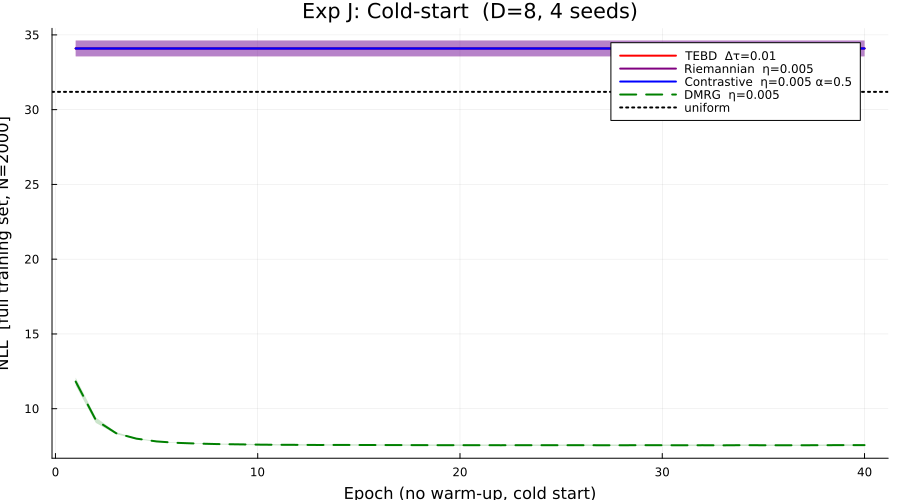

In [9]:
ep_J = 1:n_J
mn(key) = [mean(r[key][ep] for r in results_J) for ep in 1:n_J]
sd(key) = [std( r[key][ep] for r in results_J) for ep in 1:n_J]

p_J = plot(
    xlabel = "Epoch (no warm-up, cold start)",
    ylabel = "NLL  [full training set, N=$(N_train)]",
    title  = "Exp J: Cold-start  (D=$(D_J), $(seeds_J) seeds)",
)
plot!(p_J, ep_J, mn(:tebd); ribbon=sd(:tebd), label="TEBD  Δτ=$(Δτ_J)",                      color=:red,    fillalpha=0.2)
plot!(p_J, ep_J, mn(:riem); ribbon=sd(:riem), label="Riemannian  η=$(η_J)",                   color=:purple, fillalpha=0.2)
plot!(p_J, ep_J, mn(:cont); ribbon=sd(:cont), label="Contrastive  η=$(η_J) α=$(α_J)",         color=:blue,   fillalpha=0.2)
plot!(p_J, ep_J, mn(:dmrg); ribbon=sd(:dmrg), label="DMRG  η=$(η_J)",                         color=:green,  fillalpha=0.2, linestyle=:dash)
hline!(p_J, [Ml*log(d)]; label="uniform", color=:black, linestyle=:dot)
display(p_J)

---
## 6. Experiment K — Contrastive strength α sweep (warm-start)

Start from 10-epoch DMRG warm-up, fine-tune 50 epochs.
α=0 reduces to plain Riemannian gradient (baseline).

In [10]:
D_K     = 8
n_warm  = 10
n_fine  = 50
seeds_K = 3
η_K     = 0.005
M_neg_K = 200
α_vals  = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0]

K_results = Dict{Float64, Vector{Vector{Float64}}}()

for α_v in α_vals
    seed_nlls = Vector{Vector{Float64}}()
    for seed in 1:seeds_K
        mps_k = init_mps(Ml, d, D_K; T=Float64, rng=MersenneTwister(seed))
        left_canonicalize_mps!(mps_k)
        train_mps!(mps_k, xi_train, n_warm, η_K, D_K, 1e-10; verbose=false, nll_samples=400)

        rng_k = MersenneTwister(seed + 400)
        hist  = train_mps_contrastive!(mps_k, xi_train, n_fine, η_K, α_v, D_K, M_neg_K;
                                       verbose=false, nll_samples=size(xi_train,1), rng=rng_k)
        push!(seed_nlls, hist)
    end
    K_results[α_v] = seed_nlls
    @printf "α = %.2f  →  final NLL = %.4f  (mean %d seeds)\n" α_v mean(s[end] for s in seed_nlls) seeds_K
end
println("Done.")

α = 0.00  →  final NLL = 7.7123  (mean 3 seeds)
α = 0.05  →  final NLL = 7.6977  (mean 3 seeds)
α = 0.10  →  final NLL = 7.6831  (mean 3 seeds)
α = 0.20  →  final NLL = 7.6530  (mean 3 seeds)
α = 0.50  →  final NLL = 7.6119  (mean 3 seeds)
α = 1.00  →  final NLL = 7.6127  (mean 3 seeds)
Done.


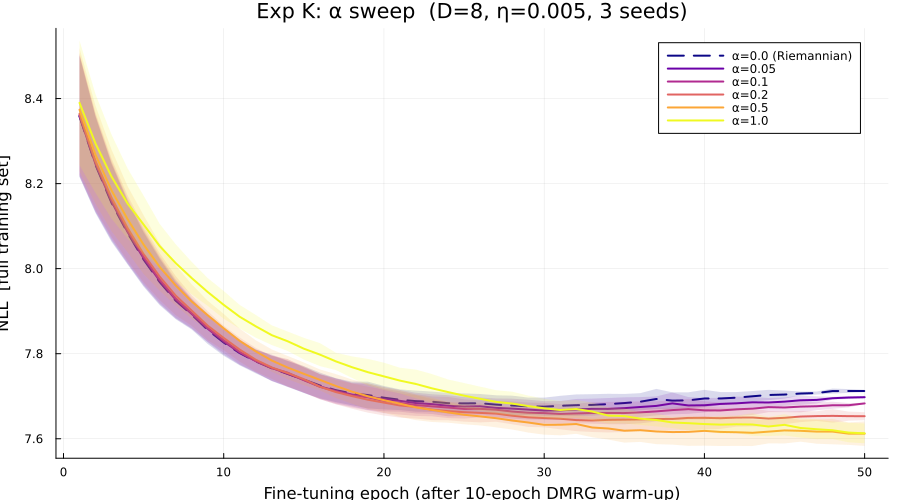

In [11]:
palette_K = cgrad(:plasma, length(α_vals); categorical=true)
ep_K      = 1:n_fine

p_K = plot(
    xlabel = "Fine-tuning epoch (after $(n_warm)-epoch DMRG warm-up)",
    ylabel = "NLL  [full training set]",
    title  = "Exp K: α sweep  (D=$(D_K), η=$(η_K), $(seeds_K) seeds)",
)
for (ci, α_v) in enumerate(α_vals)
    mn_k = [mean(K_results[α_v][s][ep] for s in 1:seeds_K) for ep in 1:n_fine]
    sd_k = [std( K_results[α_v][s][ep] for s in 1:seeds_K) for ep in 1:n_fine]
    label_str = α_v == 0.0 ? "α=0.0 (Riemannian)" : "α=$(α_v)"
    ls    = α_v == 0.0 ? :dash : :solid
    plot!(p_K, ep_K, mn_k; ribbon=sd_k, label=label_str,
          color=palette_K[ci], fillalpha=0.15, linestyle=ls)
end
display(p_K)

---
## 7. Experiment L — Full comparison after warm-up

Best α from Exp K.  All methods fine-tune for 60 epochs from the same 10-epoch DMRG warm-up.

In [12]:
best_α = α_vals[argmin([mean(K_results[α][s][end] for s in 1:seeds_K) for α in α_vals])]
@printf "Best α from Exp K: %.2f\n" best_α

D_L     = 8
n_fine_L = 60
seeds_L  = 4
η_L      = 0.005
M_neg_L  = 200

function run_exp_L(seed)
    mps_warm = init_mps(Ml, d, D_L; T=Float64, rng=MersenneTwister(seed))
    left_canonicalize_mps!(mps_warm)
    train_mps!(mps_warm, xi_train, n_warm, η_L, D_L, 1e-10; verbose=false, nll_samples=400)
    nll_warm = nll_mps(mps_warm, xi_train; n_samples=size(xi_train,1))
    @printf "  Seed %d  warm-up NLL = %.4f\n" seed nll_warm

    mps_tebd  = deepcopy(mps_warm)
    mps_riem  = deepcopy(mps_warm)
    mps_cont  = deepcopy(mps_warm)
    mps_dmrg  = deepcopy(mps_warm)

    rng_l = MersenneTwister(seed + 500)

    hist_tebd = train_mps_tebd!(mps_tebd, xi_train, n_fine_L, Δτ_J, D_L; verbose=false, nll_samples=size(xi_train,1))
    hist_riem = train_mps_2site_riemannian!(mps_riem, xi_train, n_fine_L, η_L, D_L; verbose=false, nll_samples=size(xi_train,1))
    hist_cont = train_mps_contrastive!(mps_cont, xi_train, n_fine_L, η_L, best_α, D_L, M_neg_L;
                                       verbose=false, nll_samples=size(xi_train,1), rng=rng_l)
    hist_dmrg = train_mps!(mps_dmrg, xi_train, n_fine_L, η_L, D_L, 1e-10; verbose=false, nll_samples=size(xi_train,1))

    @printf "  Final: TEBD=%.3f  Riem=%.3f  Cont(α=%.2f)=%.3f  DMRG=%.3f\n" hist_tebd[end] hist_riem[end] best_α hist_cont[end] hist_dmrg[end]
    (tebd=hist_tebd, riem=hist_riem, cont=hist_cont, dmrg=hist_dmrg)
end

println("Running Exp L  ($(seeds_L) seeds × warm-up + $(n_fine_L) epochs fine-tuning) …")
results_L = [run_exp_L(s) for s in 1:seeds_L]
println("Done.")

Best α from Exp K: 0.50
Running Exp L  (4 seeds × warm-up + 60 epochs fine-tuning) …
  Seed 1  warm-up NLL = 8.4727
  Final: TEBD=8.371  Riem=7.750  Cont(α=0.50)=7.617  DMRG=7.440
  Seed 2  warm-up NLL = 8.7033
  Final: TEBD=8.668  Riem=7.731  Cont(α=0.50)=7.611  DMRG=7.397
  Seed 3  warm-up NLL = 8.3450
  Final: TEBD=8.268  Riem=7.729  Cont(α=0.50)=7.604  DMRG=7.407
  Seed 4  warm-up NLL = 8.3299
  Final: TEBD=8.271  Riem=7.807  Cont(α=0.50)=7.648  DMRG=7.459
Done.


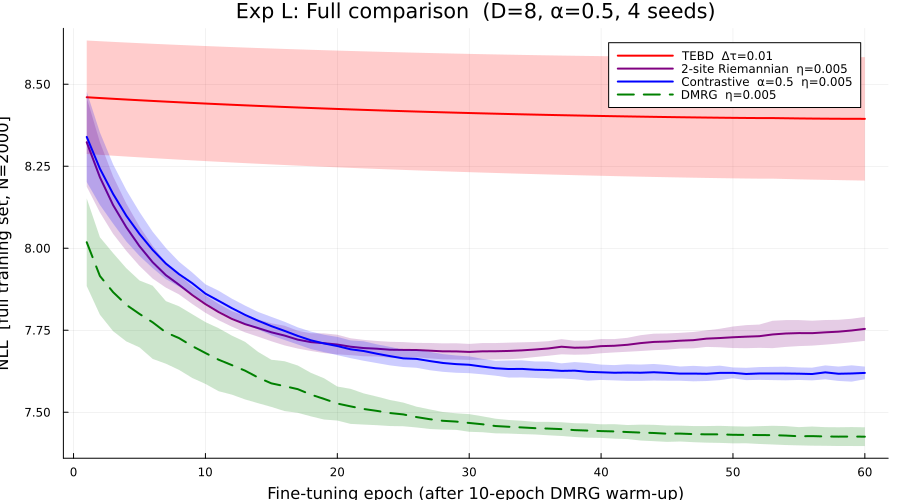

In [13]:
ep_L = 1:n_fine_L
mL(key) = [mean(r[key][ep] for r in results_L) for ep in 1:n_fine_L]
sL(key) = [std( r[key][ep] for r in results_L) for ep in 1:n_fine_L]

p_L = plot(
    xlabel = "Fine-tuning epoch (after $(n_warm)-epoch DMRG warm-up)",
    ylabel = "NLL  [full training set, N=$(N_train)]",
    title  = "Exp L: Full comparison  (D=$(D_L), α=$(best_α), $(seeds_L) seeds)",
)
plot!(p_L, ep_L, mL(:tebd); ribbon=sL(:tebd), label="TEBD  Δτ=$(Δτ_J)",                 color=:red,    fillalpha=0.2)
plot!(p_L, ep_L, mL(:riem); ribbon=sL(:riem), label="2-site Riemannian  η=$(η_L)",       color=:purple, fillalpha=0.2)
plot!(p_L, ep_L, mL(:cont); ribbon=sL(:cont), label="Contrastive  α=$(best_α)  η=$(η_L)", color=:blue,   fillalpha=0.2)
plot!(p_L, ep_L, mL(:dmrg); ribbon=sL(:dmrg), label="DMRG  η=$(η_L)",                    color=:green,  fillalpha=0.2, linestyle=:dash)
display(p_L)

---
## 8. Summary

**To be filled after running experiments.**

Key questions:
1. Does the contrastive phase break cold-start degeneracy? (Exp J)
2. What is the optimal α? (Exp K)  
3. Does contrastive outperform Riemannian after warm-up? (Exp L)
4. Does the explicit model-phase push the MPS toward the DMRG solution?

---
## Exp M — M_neg sweep  (how many model samples do we need?)

Fix α=1.0 (pure contrastive — most sensitive to sample count), warm-start with 10 DMRG epochs,
then sweep M_neg ∈ {50, 200, 500, 1000}.  Hypothesis: larger M_neg lowers variance and lets
α=1.0 beat α=0.5 cleanly.

## Exp N — Adam vs SGD  (does adaptive learning rate close the gap to DMRG?)

Fix M_neg=500, compare four methods × warm-start:
- Riemannian SGD  (α=0, use_adam=false)
- Riemannian Adam (α=0, use_adam=true)
- Contrastive SGD  (α=0.5, use_adam=false)
- Contrastive Adam (α=0.5, use_adam=true)
- DMRG (`train_mps!`, reference)

Riemannian (α=0)       → final NLL = 7.7123
α=1.0  M_neg =   50  → final NLL = 7.6361
α=1.0  M_neg =  200  → final NLL = 7.6176
α=1.0  M_neg =  500  → final NLL = 7.6091
α=1.0  M_neg = 1000  → final NLL = 7.6022
Done.


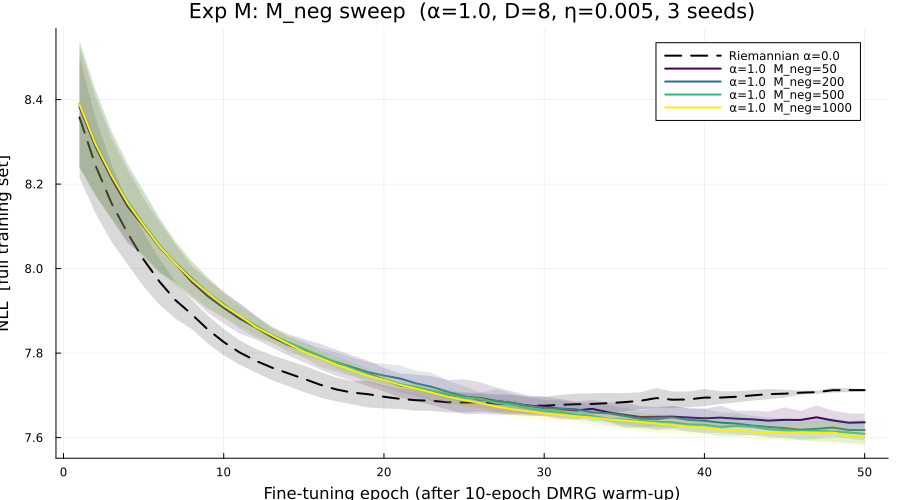

In [14]:
# ── Exp M: M_neg sweep  ────────────────────────────────────────────────────────
# α=1.0 (full contrastive, no normalization approximation), SGD, warm-start.
# Baseline: α=0.0 (Riemannian, M_neg irrelevant) included as reference.

D_M      = 8
n_warm_M = 10
n_fine_M = 50
seeds_M  = 3
η_M      = 0.005
α_M      = 1.0                          # pure contrastive
Mneg_vals = [50, 200, 500, 1000]

M_results = Dict{Int, Vector{Vector{Float64}}}()

# Reference: Riemannian (α=0) — unaffected by M_neg
riem_M_results = Vector{Vector{Float64}}()
for seed in 1:seeds_M
    mps_r = init_mps(Ml, d, D_M; T=Float64, rng=MersenneTwister(seed))
    left_canonicalize_mps!(mps_r)
    train_mps!(mps_r, xi_train, n_warm_M, η_M, D_M, 1e-10; verbose=false, nll_samples=400)
    hist = train_mps_contrastive!(mps_r, xi_train, n_fine_M, η_M, 0.0, D_M, 1;
                                  verbose=false, nll_samples=size(xi_train,1),
                                  rng=MersenneTwister(seed+600))
    push!(riem_M_results, hist)
end
@printf "Riemannian (α=0)       → final NLL = %.4f\n" mean(s[end] for s in riem_M_results)

for M_n in Mneg_vals
    seed_nlls = Vector{Vector{Float64}}()
    for seed in 1:seeds_M
        mps_m = init_mps(Ml, d, D_M; T=Float64, rng=MersenneTwister(seed))
        left_canonicalize_mps!(mps_m)
        train_mps!(mps_m, xi_train, n_warm_M, η_M, D_M, 1e-10; verbose=false, nll_samples=400)
        rng_m = MersenneTwister(seed + 700)
        hist  = train_mps_contrastive!(mps_m, xi_train, n_fine_M, η_M, α_M, D_M, M_n;
                                       verbose=false, nll_samples=size(xi_train,1), rng=rng_m)
        push!(seed_nlls, hist)
    end
    M_results[M_n] = seed_nlls
    @printf "α=1.0  M_neg = %4d  → final NLL = %.4f\n" M_n mean(s[end] for s in seed_nlls)
end
println("Done.")

# ── Exp M plot ─────────────────────────────────────────────────────────────────
palette_M = cgrad(:viridis, length(Mneg_vals); categorical=true)
ep_M = 1:n_fine_M

p_M = plot(
    xlabel = "Fine-tuning epoch (after $(n_warm_M)-epoch DMRG warm-up)",
    ylabel = "NLL  [full training set]",
    title  = "Exp M: M_neg sweep  (α=$(α_M), D=$(D_M), η=$(η_M), $(seeds_M) seeds)",
)
mn_r = [mean(riem_M_results[s][ep] for s in 1:seeds_M) for ep in 1:n_fine_M]
sd_r = [std( riem_M_results[s][ep] for s in 1:seeds_M) for ep in 1:n_fine_M]
plot!(p_M, ep_M, mn_r; ribbon=sd_r, label="Riemannian α=0.0", color=:black,
      fillalpha=0.15, linestyle=:dash)
for (ci, M_n) in enumerate(Mneg_vals)
    mn_m = [mean(M_results[M_n][s][ep] for s in 1:seeds_M) for ep in 1:n_fine_M]
    sd_m = [std( M_results[M_n][s][ep] for s in 1:seeds_M) for ep in 1:n_fine_M]
    plot!(p_M, ep_M, mn_m; ribbon=sd_m, label="α=1.0  M_neg=$(M_n)",
          color=palette_M[ci], fillalpha=0.15)
end
display(p_M)

Running Exp N  (4 seeds × warm-up + 60 epochs) …
  Seed 1  warm-up NLL = 8.4727
    Riem SGD     final NLL = 7.7500
    Riem Adam    final NLL = 8.4484
    Cont SGD     final NLL = 7.6248
    Cont Adam    final NLL = 7.8041
    DMRG         final NLL = 7.4397
  Seed 2  warm-up NLL = 8.7033
    Riem SGD     final NLL = 7.7311
    Riem Adam    final NLL = 8.1209
    Cont SGD     final NLL = 7.6034
    Cont Adam    final NLL = 7.8080
    DMRG         final NLL = 7.3970
  Seed 3  warm-up NLL = 8.3450
    Riem SGD     final NLL = 7.7286
    Riem Adam    final NLL = 8.3721
    Cont SGD     final NLL = 7.5849
    Cont Adam    final NLL = 7.8269
    DMRG         final NLL = 7.4071
  Seed 4  warm-up NLL = 8.3299
    Riem SGD     final NLL = 7.8069
    Riem Adam    final NLL = 8.3827
    Cont SGD     final NLL = 7.6355
    Cont Adam    final NLL = 7.9021
    DMRG         final NLL = 7.4586
Done.


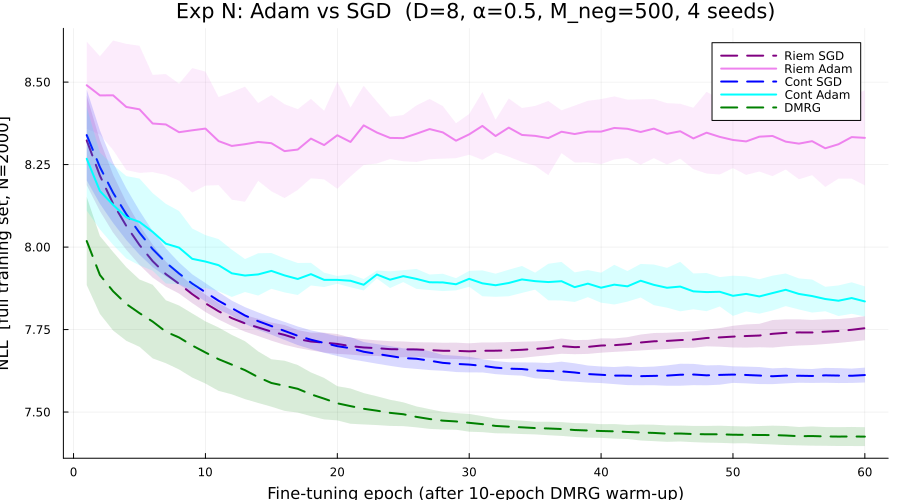

In [15]:
# ── Exp N: Adam vs SGD  ────────────────────────────────────────────────────────
# Fixed M_neg=500, α=0.5, D=8.  Four gradient methods + DMRG reference.
# Adam uses the same η as SGD — Adam's adaptive scaling handles the effective
# step size; no separate η tuning needed.

D_N      = 8
n_warm_N = 10
n_fine_N = 60
seeds_N  = 4
η_N      = 0.005
α_N      = 0.5
M_neg_N  = 500

methods_N = [
    ("Riem SGD",      (mps, rng) -> train_mps_contrastive!(mps, xi_train, n_fine_N, η_N, 0.0, D_N, 1;
                        verbose=false, nll_samples=size(xi_train,1), rng=rng)),
    ("Riem Adam",     (mps, rng) -> train_mps_contrastive!(mps, xi_train, n_fine_N, η_N, 0.0, D_N, 1;
                        verbose=false, nll_samples=size(xi_train,1), rng=rng, use_adam=true)),
    ("Cont SGD",      (mps, rng) -> train_mps_contrastive!(mps, xi_train, n_fine_N, η_N, α_N, D_N, M_neg_N;
                        verbose=false, nll_samples=size(xi_train,1), rng=rng)),
    ("Cont Adam",     (mps, rng) -> train_mps_contrastive!(mps, xi_train, n_fine_N, η_N, α_N, D_N, M_neg_N;
                        verbose=false, nll_samples=size(xi_train,1), rng=rng, use_adam=true)),
    ("DMRG",          (mps, rng) -> train_mps!(mps, xi_train, n_fine_N, η_N, D_N, 1e-10;
                        verbose=false, nll_samples=size(xi_train,1))),
]
N_colors = [:purple, :violet, :blue, :cyan, :green]
N_styles = [:dash, :solid, :dash, :solid, :dash]

N_results = Dict{String, Vector{Vector{Float64}}}(name => [] for (name, _) in methods_N)

println("Running Exp N  ($(seeds_N) seeds × warm-up + $(n_fine_N) epochs) …")
for seed in 1:seeds_N
    # shared warm-up MPS
    mps_warm = init_mps(Ml, d, D_N; T=Float64, rng=MersenneTwister(seed))
    left_canonicalize_mps!(mps_warm)
    train_mps!(mps_warm, xi_train, n_warm_N, η_N, D_N, 1e-10; verbose=false, nll_samples=400)
    @printf "  Seed %d  warm-up NLL = %.4f\n" seed nll_mps(mps_warm, xi_train; n_samples=size(xi_train,1))

    for (name, trainer) in methods_N
        mps_c = deepcopy(mps_warm)
        rng_n = MersenneTwister(seed + 800)
        hist  = trainer(mps_c, rng_n)
        push!(N_results[name], hist)
        @printf "    %-12s final NLL = %.4f\n" name hist[end]
    end
end
println("Done.")

# ── Exp N plot ─────────────────────────────────────────────────────────────────
ep_N = 1:n_fine_N

p_N = plot(
    xlabel = "Fine-tuning epoch (after $(n_warm_N)-epoch DMRG warm-up)",
    ylabel = "NLL  [full training set, N=$(N_train)]",
    title  = "Exp N: Adam vs SGD  (D=$(D_N), α=$(α_N), M_neg=$(M_neg_N), $(seeds_N) seeds)",
)
for (i, (name, _)) in enumerate(methods_N)
    mn_n = [mean(N_results[name][s][ep] for s in 1:seeds_N) for ep in 1:n_fine_N]
    sd_n = [std( N_results[name][s][ep] for s in 1:seeds_N) for ep in 1:n_fine_N]
    plot!(p_N, ep_N, mn_n; ribbon=sd_n, label=name,
          color=N_colors[i], fillalpha=0.15, linestyle=N_styles[i])
end
display(p_N)